Imports


In [51]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
import matplotlib.pyplot as plt
import numpy as np
import os
import json

In [36]:
zip_path = r'D:\Work\Projects\plant desiese\archive.zip'


In [37]:
import zipfile
extract_path = "D:\Work\Projects\plant desiese"  # folder where you want to unzip

# Create folder if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully at:", extract_path)


✅ Dataset extracted successfully at: D:\Work\Projects\plant desiese


In [38]:
dataset_path=r'D:\Work\Projects\plant desiese\Dataset'

Data Preprocessing


In [39]:
img_size = (128, 128)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

num_classes = len(train_gen.class_indices)
print(f"Detected {num_classes} classes:", train_gen.class_indices)


Found 28589 images belonging to 23 classes.
Found 7136 images belonging to 23 classes.
Detected 23 classes: {'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 4, 'Corn_(maize)___Common_rust_': 5, 'Corn_(maize)___Northern_Leaf_Blight': 6, 'Corn_(maize)___healthy': 7, 'Pepper__bell___Bacterial_spot': 8, 'Pepper__bell___healthy': 9, 'Potato___Early_blight': 10, 'Potato___Late_blight': 11, 'Potato___healthy': 12, 'Tomato_Bacterial_spot': 13, 'Tomato_Early_blight': 14, 'Tomato_Late_blight': 15, 'Tomato_Leaf_Mold': 16, 'Tomato_Septoria_leaf_spot': 17, 'Tomato_Spider_mites_Two_spotted_spider_mite': 18, 'Tomato__Target_Spot': 19, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 20, 'Tomato__Tomato_mosaic_virus': 21, 'Tomato_healthy': 22}


Model Architecture

In [40]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

d:\Work\Projects\plant desiese\cropenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,522,839 (24.88 MB)

 Trainable params: 6,522,391 (24.88 MB)

 Non-trainable params: 448 (1.75 KB)

In [41]:
epochs =  5 # For demo; increase later to 20+
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs
)

Epoch 1/5
894/894 ━━━━━━━━━━━━━━━━━━━━ 618s 689ms/step - accuracy: 0.3240 - loss: 2.4950 - val_accuracy: 0.4463 - val_loss: 2.0859
Epoch 2/5
894/894 ━━━━━━━━━━━━━━━━━━━━ 512s 573ms/step - accuracy: 0.4228 - loss: 1.8758 - val_accuracy: 0.5132 - val_loss: 1.5650
Epoch 3/5
894/894 ━━━━━━━━━━━━━━━━━━━━ 512s 573ms/step - accuracy: 0.4791 - loss: 1.6669 - val_accuracy: 0.5263 - val_loss: 1.7420
Epoch 4/5
894/894 ━━━━━━━━━━━━━━━━━━━━ 512s 572ms/step - accuracy: 0.5491 - loss: 1.4287 - val_accuracy: 0.5307 - val_loss: 1.8684
Epoch 5/5
894/894 ━━━━━━━━━━━━━━━━━━━━ 510s 571ms/step - accuracy: 0.6022 - loss: 1.2641 - val_accuracy: 0.5230 - val_loss: 1.5947


In [49]:
more_epochs = 5
new_history = model.fit(
    train_gen,
    validation_data=val_gen,
    initial_epoch=history.epoch[-1] + 1,  # Continue from last epoch
    epochs=history.epoch[-1] + 1 + more_epochs
)


Epoch 6/10


ValueError: Unknown variable: <Variable path=sequential_2/conv2d_9/kernel, shape=(3, 3, 3, 32), dtype=float32>. This optimizer can only be called for the variables it was originally built with. When working with a new set of variables, you should recreate a new optimizer instance.

In [52]:
with open("class_names.json", "w") as f:
    json.dump(
        [k for k, v in sorted(train_gen.class_indices.items(), key=lambda x: x[1])],
        f
    )

In [ ]:
for key in history.history.keys():
    history.history[key].extend(new_history.history[key])


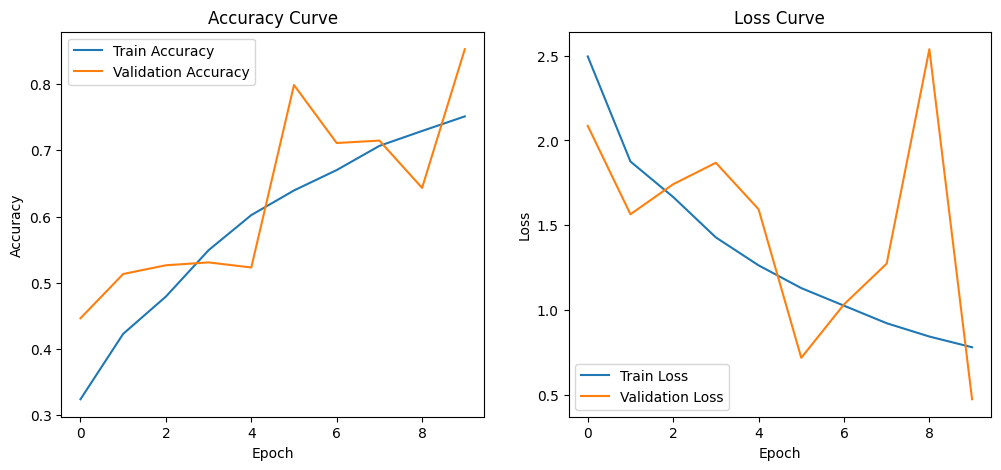

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
save_path = 'D:\Work\Projects\plant desiese\cropcare_model.h5'
model.save(save_path)
print(f"Model saved at {save_path}")


Model saved at D:\Work\Projects\plant desiese\cropcare_model.h5


Testing


In [ ]:
#Loading the model
model = load_model('D:\Work\Projects\plant desiese\cropcare_model.h5')
print("✅ Model loaded successfully")



✅ Model loaded successfully


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

✅ Actual Label: Tomato_Spider_mites_Two_spotted_spider_mite
🤖 Predicted Label: Tomato__Target_Spot (58.02% confidence)


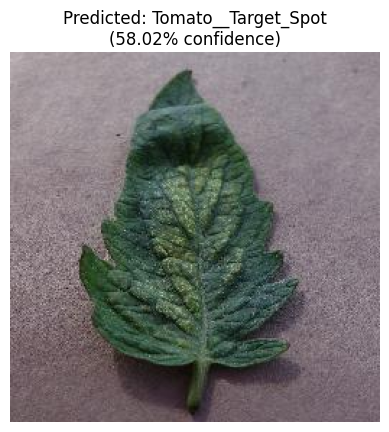

In [ ]:
import random
from tensorflow.keras.preprocessing import image

# Get all class folders
class_folders = os.listdir(dataset_path)

# Pick a random class folder
random_class = random.choice(class_folders)

# Get all images from that class folder
image_files = os.listdir(os.path.join(dataset_path, random_class))

# Pick a random image from that folder
random_image = random.choice(image_files)

# Construct full path
test_image_path = os.path.join(dataset_path, random_class, random_image)

# Load and preprocess
img = image.load_img(test_image_path, target_size=img_size)
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
predicted_class = list(train_gen.class_indices.keys())[np.argmax(pred)]
confidence = np.max(pred) * 100

# Display results
print(f"\n✅ Actual Label: {random_class}")
print(f"🤖 Predicted Label: {predicted_class} ({confidence:.2f}% confidence)")

plt.imshow(image.load_img(test_image_path))
plt.title(f"Predicted: {predicted_class}\n({confidence:.2f}% confidence)")
plt.axis('off')
plt.show()
